# Détection de Texte, Visualisation, et Cartographie - 27/04/2026

Dans ce notebook, nous verrons les trois derniers thèmes de notre cours : l'extraction de texte, les bases de la data visualisation, et une introduction à la cartographie.

Comme toujours, toutes les cellules peuvent être executées dans l'ordre, mais essayez de prédire la sortie de chaque cellule avant de l'exécuter.
N'hésitez pas à jouer avec le code, le bidouiller pour tester des alternatives — c'est l'un des grands avantages d'utiliser un notebook.

# 1. Extraction de Texte

Pour l'extraction de texte, les modèles spécialisés ont atteint un niveau de flexibilité qui nous permet de ne pas avoir recours aux LLMs.

Voyons-voir comment un réseau tel s'en sort pour une image aux couches et fonctions textuelles mêlées.

Partons de cette image :

![image](./data/victorian_newspaper.jpg)

qui multiplie les difficultés.

❓ Quelles sont-elles selon vous ?


- Différentes typos
- Multiplication des sections, sans format constant
- Bordures ou non
- Inserts d'images
- Légendes d'images

Ces difficultés, autrefois, auraient rendu l'extraction de ce genre de texte très difficile, nécessitant la combinaison de modèles spécifiques, dont les résultats pouvaient être ardus à unir.

C'est aujourd'hui -- à peu de choses près -- un problème clos.

## Modèle spécifique : Paddle OCR

Le modèle Paddle OCR, développé par Baidu, est remarquablement versatile, capable de gérer toutes ces difficultés -- en plus d'autre, comme la courbe des pages où la pluralité des langues.

![image|100](https://raw.githubusercontent.com/cuicheng01/PaddleX_doc_images/main/images/paddleocr/README/PaddleOCR-VL_demo.gif)

Plutôt que de nous lancer dans l'installation de toutes les librairies nécessaires, utilisons plutôt l'interface Web de ce modèle -- accessible [ici](https://www.paddleocr.com/).

Il suffit de glisser-déposer notre document, et nous pouvons interagir avec les résultats.

Ainsi que récupérer le ```.JSON``` qui est produit, et que nous pouvons explorer ici.

In [1]:
import cv2
import json
import matplotlib.pyplot as plt
# Load image
image = cv2.imread("./data/victorian_newspaper.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# Load JSON
with open("./victorian_newspaper.json") as f:
    data = json.load(f)


Regardons ce qui est produit par ce réseau : 

In [2]:
data

[{'prunedResult': {'model_settings': {'use_doc_preprocessor': False,
    'use_layout_detection': True,
    'use_chart_recognition': False,
    'use_seal_recognition': True,
    'use_ocr_for_image_block': False,
    'format_block_content': True,
    'merge_layout_blocks': True,
    'markdown_ignore_labels': ['number',
     'footnote',
     'header',
     'header_image',
     'footer',
     'footer_image',
     'aside_text'],
    'return_layout_polygon_points': True},
   'parsing_res_list': [{'block_label': 'header',
     'block_content': 'DE BILLE ORINIGES',
     'block_bbox': [252, 77, 347, 85],
     'block_id': 0,
     'group_id': 0,
     'block_polygon_points': [[252.0, 76.99999237060547],
      [346.0, 76.99999237060547],
      [346.0, 83.99999237060547],
      [252.0, 83.99999237060547]]},
    {'block_label': 'header',
     'block_content': 'A9903: 17.795',
     'block_bbox': [460, 76, 511, 84],
     'block_id': 1,
     'group_id': 1,
     'block_polygon_points': [[460.0, 76.0],
  

Et un élément ...

In [3]:
data[0]['prunedResult']['parsing_res_list'][15]

{'block_label': 'doc_title',
 'block_content': '# NURSING MOTHERS',
 'block_bbox': [324, 120, 502, 172],
 'block_id': 15,
 'block_order': 10,
 'group_id': 15,
 'block_polygon_points': [[324.0, 120.0],
  [502.0, 120.0],
  [502.0, 172.0],
  [324.0, 172.0]]}

Si l'on cherche à tout représenter :

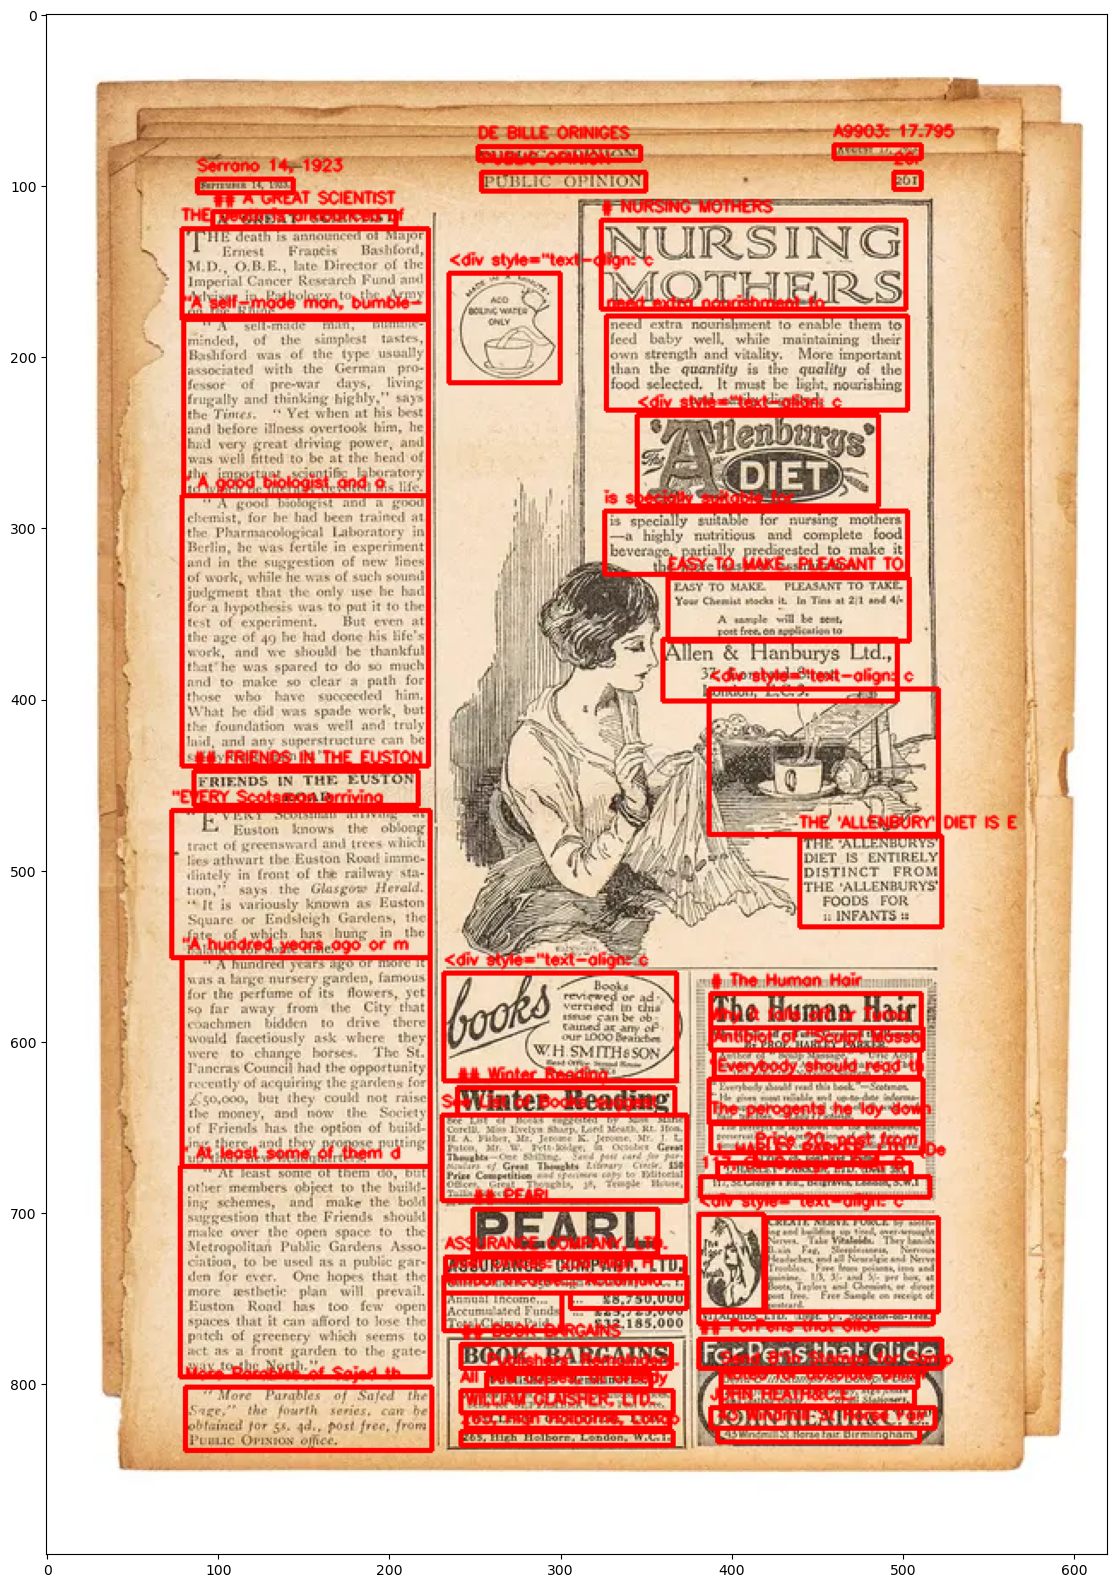

In [26]:

for item in data[0]['prunedResult']['parsing_res_list']:
    x1, y1, x2, y2 = item["block_bbox"]
    text = item["block_content"]

    # Draw rectangle
    cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

    # Put text above box
    cv2.putText(image, text[:25], (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.3, (255, 0, 0), 1, cv2.LINE_AA)
plt.figure(figsize = (20,20))
plt.imshow(image)
plt.show()

❗ Remarquez bien que cette représentation, simpliste, ne tient pas compte de toute la complexité de l'output : 
- hierarchie des paragraphes,
- catégories,
- extractions d'images,
- détection de légendes pour les images,
- classification,
- etc.


Ce sont des choses que vous pouvez prendre en compte si vous utilisez ce genre de réseau.

# 2. Visualisation

Voyons ensuis comment créer des diagrammes capables de combiner différents sous-graphes (subplots), annotations, ou différents éléments sur la même figure.

L'élément central à comprendre est la manière dont `matplotlib` utilise les `Axes`.

Les `Axes` (ou `ax.`) sont les objets que vous voulez remplir (ou peupler) d'information à afficher. Vous pouvez les arranger, les modifier comme vous voulez de manière indépendante.

C'est en modifiant les propriété des objets `ax.` que vous pouvez jouer avec les propriétés suivantes : 
- titres,
- limites des axes,
- légende
- typo et taille,
- couleurs et fond
- etc.


Commençons par importer les librairies essentielles que nous avons déjà vues :

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Nous allons créer un graphe de plus en plus personnalisé.

Pour cela, "dé-commentez" chaque bloc l'un après l'autre, et ré-executez la cellule à chaque fois.

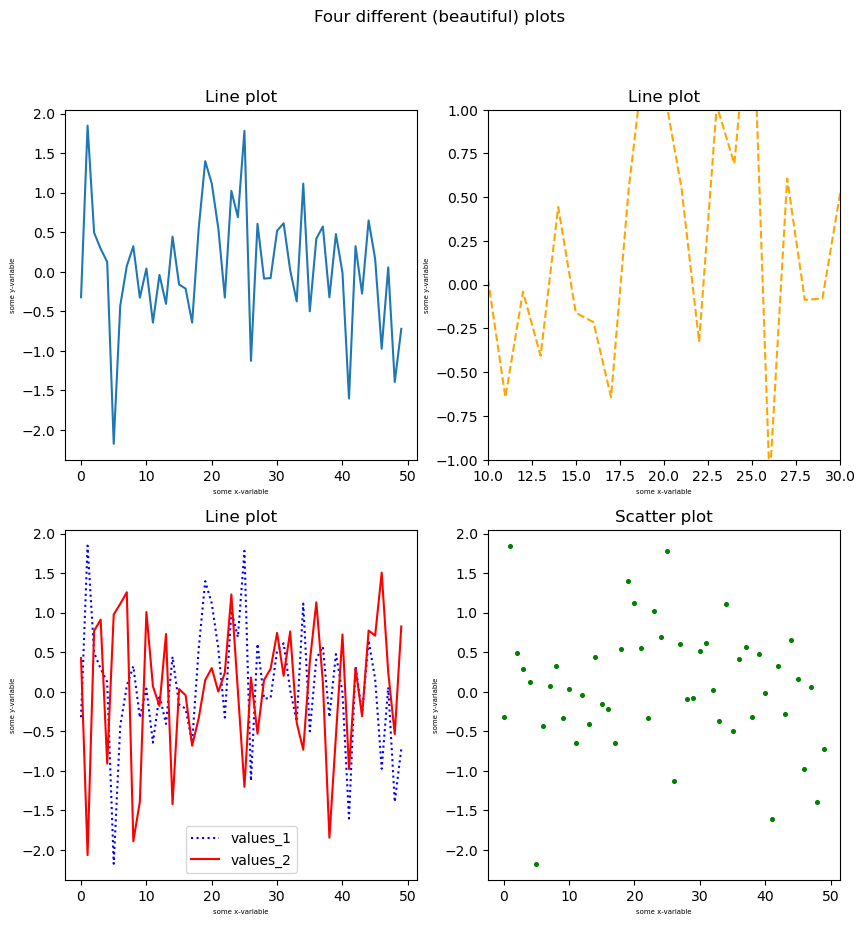

In [6]:
# Commençons par créer des points aléatoires, que nous allons afficher de différentes manières.
x_values = range(50)
y_values_1 = np.random.randn(50)
y_values_2 = np.random.randn(50)


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,10))


# #BLOC 1. En haut à gauche: line-plotting avec les valeurs x et y.
axes[0,0].plot(x_values,y_values_1)
# # ------------ #

# #BLOC 2. En haut à droite: changer la couleur et le style de ligne
axes[0,1].plot(x_values,y_values_1, color='orange', linestyle='--')
# # ------------ #

# #BLOC 3. En bas à gauche: superposer les deux lignes
axes[1,0].plot(x_values,y_values_1, color='blue', linestyle=':', label='values_1')
axes[1,0].plot(x_values,y_values_2, color='red', linestyle='-', label='values_2')
# # ------------ #

# #BLOC 5. En bas à droite : utiliser plutôt un scatter)plot
axes[1,1].scatter(x_values, y_values_1, color='green', s=7)
# # ------------ #

# #BLOC 5. Ajouter les titres
axes[0,0].set_title('Line plot')
axes[0,1].set_title('Line plot')
axes[1,0].set_title('Line plot')
axes[1,1].set_title('Scatter plot')


# # ------------ #

#BLOC 6. Ajouter une légende. Pour cela, il faut avoir spécifié les labels au moment de l'affichage.
axes[1,0].legend()
# # ------------ #

# #BLOC 7. Ajouter les titres des axes. On peut aussi jouter avec la "fontsize" pour rendre le titre plus petit.
# #❓ Quel est l'intérêt de cette boucle ?

for ax in axes.flatten():
    ax.set_xlabel('some x-variable', fontsize=5)
    ax.set_ylabel('some y-variable', fontsize=5)

# # ------------ #

# #BLOC 8. Il vous sera parfois utile de spécifier les limites de vos axes.
axes[0,1].set_xlim(10,30)
axes[0,1].set_ylim(-1,1)
# # ------------ #

# #BLOC 9. Ajouter un titre général.
# #❓ Pourquoi on appelle "fig." et non pas "ax." comme dans les autres blocs ?
fig.suptitle('Four different (beautiful) plots')
# # ------------ #

# #BLOC 10. Exporter vers une image externe.
plt.savefig('my_figure.png')
# # ------------ #

plt.show()

❗ Ici, nous avons manipulé des données numériques aléatoires. Mais cette logique de l'axe, que nous modifions et personnalisons est rigoureusement la même peu importe ce que vous affichez.

# 3. Cartographie

Voyons maintenant comment gérer et représenter des données géographiques.

## 3.1. Geocoding

Mettons, comme il est souvent le cas, que vous ayez une liste de lieux sous forme textuelle. Les convertir en information géographique s'appelle le `geocoding`.

Voyons d'abord comment récupérer les coordonnées correspondantes : latitude et longitude.

Le package que nous utiliserons pour cela s'appelle `geopy`, et l'idée est de créer un dictionnaire qui nous donne la conversion :


`{place_name : (latitude, longitude)}`

In [1]:
import geopy

Prenons comme exemple une partie du catalogue de la British Library

In [4]:
books_df = pd.read_json('./data/book_data_sample.json').head(200)

/var/folders/h0/0v0s48pj41zdnzdy7333vb4m0000gn/T/ipykernel_40509/3724133384.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  books_df = pd.read_json('./data/book_data_sample.json').head(200)


In [6]:
books_df.head()

,datefield,shelfmarks,publisher,title,edition,flickr_url_to_book_images,place,issuance,authors,date,pdf,identifier,corporate,fulltext_filename,imgs
0,1841,[British Library HMNTS 11601.ddd.2.],Privately printed,"[The Poetical Aviary, with a bird's-eye view o...",,http://www.flickr.com/photos/britishlibrary/ta...,Calcutta,monographic,{'creator': ['A. A.']},1970-01-01 00:30:41,{'1': 'lsidyv35c55757'},196,{},sample/full_texts/000000196_01_text.json,NaN
1,1888,[British Library HMNTS 9025.cc.14.],Rivingtons,[A History of Greece. Part I. From the earlies...,,http://www.flickr.com/photos/britishlibrary/ta...,London,monographic,"{'creator': ['Abbott, Evelyn']}",1970-01-01 00:31:28,{'1': 'lsidyv376da437'},4047,{},sample/full_texts/000004047_01_text.json,{'0': {'000257': ['11104648374']}}
2,"1847, 48 [1846-48]","[British Library HMNTS C.131.d.16., British Li...",Punch Office,[The Comic History of England ... With ... col...,,http://www.flickr.com/photos/britishlibrary/ta...,London,monographic,"{'contributor': ['LEECH, John - Artist'], 'cre...",1970-01-01 00:30:47,{'1': 'lsidyv38b27a31'},5382,{},sample/full_texts/000005382_01_text.json,"{'0': {'000410': ['11026944866'], '000412': ['..."
3,1892,[British Library HMNTS 10351.cc.60.],"Eden, Remington & Co.",[The Cruise of “The Tomahawk”: the story of a ...,,http://www.flickr.com/photos/britishlibrary/ta...,London,monographic,"{'creator': ['Laffan, De Courcy - Mrs']}",1970-01-01 00:31:32,{'1': 'lsidyv3c4a946a'},14627,{},sample/full_texts/000014627_01_text.json,"{'0': {'000134': ['11300364604'], '000039': ['..."
4,1863,[British Library HMNTS 9078.c.10.],Virtue Bros. & Co.,[Scenes from the Drama of European History],,http://www.flickr.com/photos/britishlibrary/ta...,London,monographic,"{'creator': ['Adams, W. H. Davenport (William ...",1970-01-01 00:31:03,{'1': 'lsidyv32c34c22'},17057,{},sample/full_texts/000017057_01_text.json,{'0': {'000005': ['11046098454']}}


In [7]:
# Commençons par extraire les lieux uniques :
all_place_names_in_df = books_df['place'].unique()

In [8]:
all_place_names_in_df

array(['Calcutta', 'London', 'Toronto', 'Omaha, Neb', 'Philadelphia',
       'Bradford-on-Avon', 'Dundee', 'New York', 'Providence', 'Selkirk',
       'Chicago', 'Edinburgh', 'Springfield, Mass', 'San Francisco',
       'New Haven', 'Boston', 'Cirencester', 'Cork', 'Delhi', 'Leeds',
       'Oswestry', 'Oxford', 'enk', 'Cambridge', '', 'Littleborough',
       'Maidstone', 'Richmond', 'Dublin', 'Coventry',
       'Edinburgh; Simpkin & Marshall', 'Wick', 'Sydney',
       'London & Edinburgh', 'R.T.S. London', 'Bradford', 'Rye',
       'New York & London', "London; Cole's Book Arcade", 'Scarborough',
       'Otley', 'London]', 'Liverpool', 'New-York', 'Swansea',
       'Greenfield', 'Preston', 'Nashville, Tenn', 'Yarmouth',
       'R. Bentley; J. Tonson; printed by T. H', 'Birmingham', 'Exeter',
       'Paisley', 'J. Wiseheart', 'Nashua', 'Framlingham', 'Newcastle',
       'Bayonne', 'Bangor, Ma', 'Smith, Elder & Co', 'Harrogate',
       'Newark, Ohio'], dtype=object)

In [9]:
# Et de la même manière qu'avec les LLMs, par initialiser notre moteur :

from geopy.geocoders import Nominatim
geolocator = Nominatim(user_agent="unigepaul")

from geopy.extra.rate_limiter import RateLimiter
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)


Pour récupérer les coordonnées, il suffit de faire appel à la fonction `geolocator.geocode()`

In [10]:
# Faisons un petit test sur les cinq premières valeurs:

for place_name in all_place_names_in_df[:5]:
    location = geolocator.geocode(place_name, timeout=None)

    print(place_name, '-->', location.address)

GeocoderRateLimited: Non-successful status code 429

❓ Que vous retourne cette fonction ?

❓ Quelles sont les propriétés de l'objet `location`?

In [16]:
location

Location(Philadelphia, Philadelphia County, Pennsylvania, United States, (39.9527237, -75.1635262, 0.0))

In [19]:
# Évitons les lieux qui proviennent des erreurs du catalogue :
bad_ones = ['enk', 'Rye', 'Smith, Elder & Co']

place2coords = {}

for place_name in all_place_names_in_df:
    if place_name not in bad_ones:
        print(place_name)
        location = geolocator.geocode(place_name, timeout=None)
        if location is not None:
            result = location.address
            place2coords[place_name] = (location.longitude, location.latitude)
        else:
            pass

Calcutta


GeocoderRateLimited: Non-successful status code 429

In [ ]:
# Ajoutons les coordonées comme nouvelle colonne de la `DataFrame`
books_df['coords'] = books_df['place'].map(place2coords)

books_df.head()

## 3.2. Geomapping

Enfin, nous voulons stocker cette information géographique d'une façon qui nous permettra de la visualiser.

C'est l'intérêt de `GeoPandas`, une sorte d'extension géographique de `Pandas`.

C'est exactement la même logique : series, dataframes, indexing, etc. 

❗ Sauf que chaque entrée doit avoir une géométrie correspondante.

C'est particulièrement puissant pour représenter l'information géographique.

In [11]:
import geopandas as gp
from shapely.geometry import Point

Étape 1: Créeons une liste de géométries (en utilisant le package géométrique `shapely`)

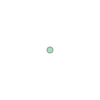

In [12]:
Point((1,2))

In [13]:
located_books = books_df.loc[books_df['coords'].notna()]
geometries = [Point(i) for i in located_books['coords'].values]

KeyError: 'coords'

- Étape 2: Créer la `GeoDataFrame`

In [ ]:
gdf = gp.GeoDataFrame(located_books, geometry=geometries)

- Étape 3: Afficher the `GeoDataFrame`

Pour visualiser une GeoDataFrame, il suffit d'utiliser la méthode `.plot().

matplotlib.axes._axes.Axes

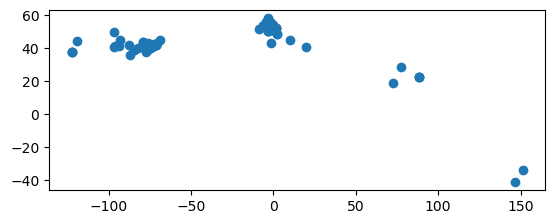

In [ ]:
type(gdf.plot())

❗ Attention, ceci renvoie un objet `matplotlib axes`.

❓ En quoi est-ce une bonne nouvelle pour nous ?

En récupérant et modifiant les axes, des couches cartographiques peuvent être combinées. Voyons voir comment ajouter un fond de carte mondiale :

In [34]:
# On peut récupérer ce fond de carte via une URL

url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gp.read_file(url)

NameError: name 'gp' is not defined

<Axes: >

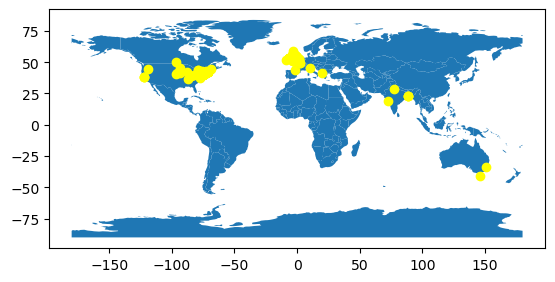

In [ ]:
basemap = world.plot()
gdf.plot(ax=basemap, color='yellow')

In [35]:
# On crée notre fond de carte en plottant ces pays et en stockant l'axe où ils sont affichés (dans la variable ax).
ax=world.plot()

# Pour ajouter une nouvelle couche, il suffit de spécifier que l'on veut afficher les données sur l'axe "ax".
gdf.plot(ax=ax, color='red')

NameError: name 'world' is not defined

Enfin, un peu de customisation.

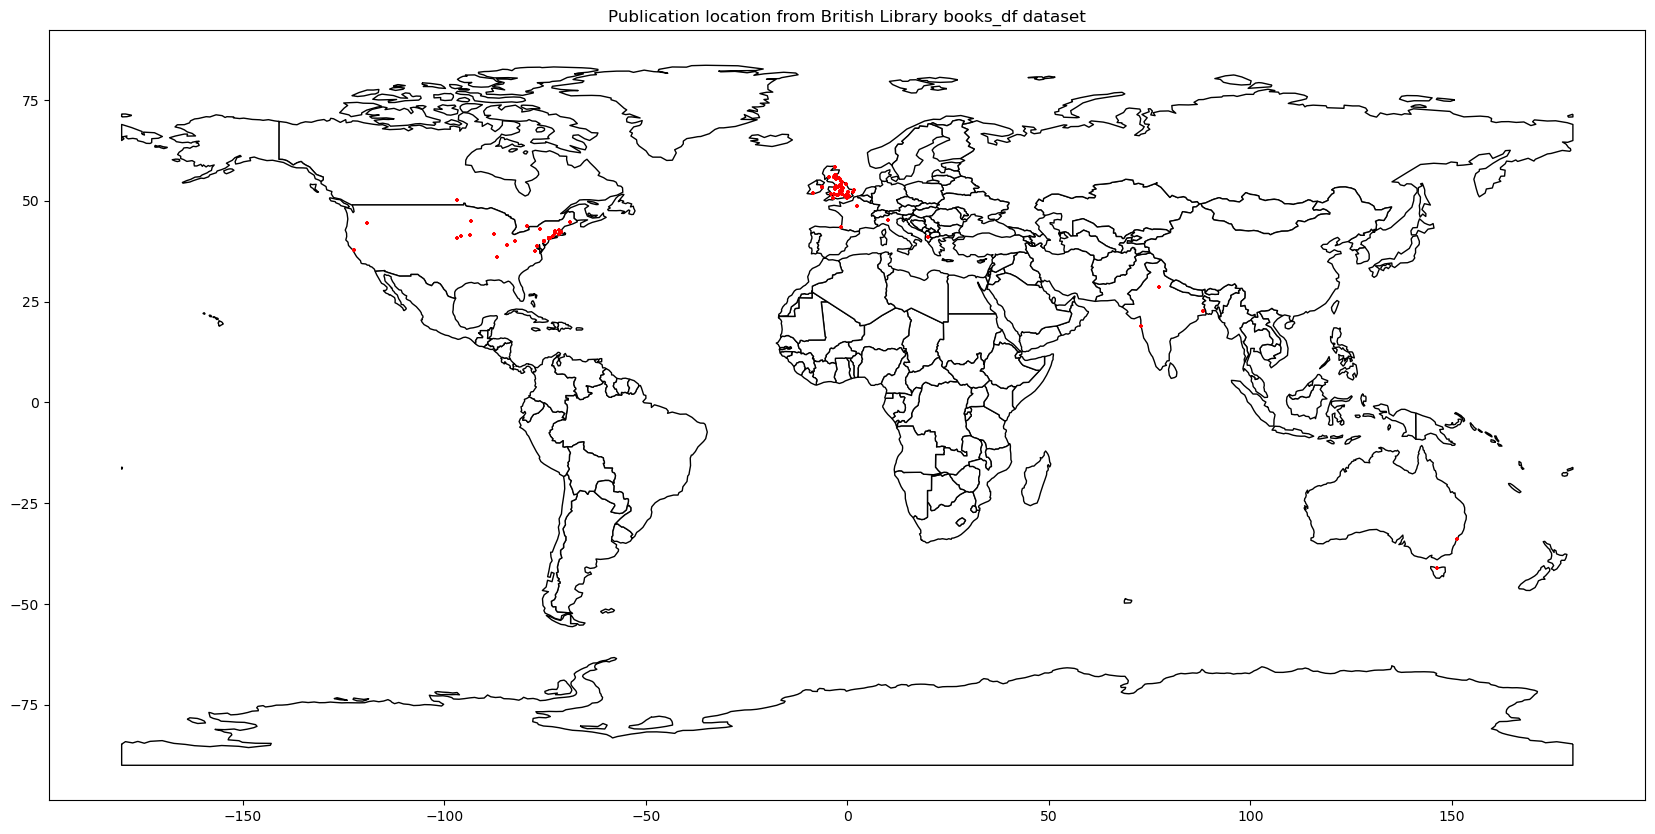

In [ ]:
# On crée notre fond de carte.
ax=world.plot(color='white', edgecolor='black', figsize=(30,10))

# On ajoute les données sur le fond de carte.
gdf.plot(ax=ax, marker='+', color='red', markersize=12)

# On spécifie le titre.
ax.set_title('Publication location from British Library books_df dataset')

plt.show()

Les fonctionnalités de `pandas` restent utiles, et l'on peut ainsi affiner nos données et notre graphe.

/Users/guhennec/miniconda3/envs/dhoxss/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


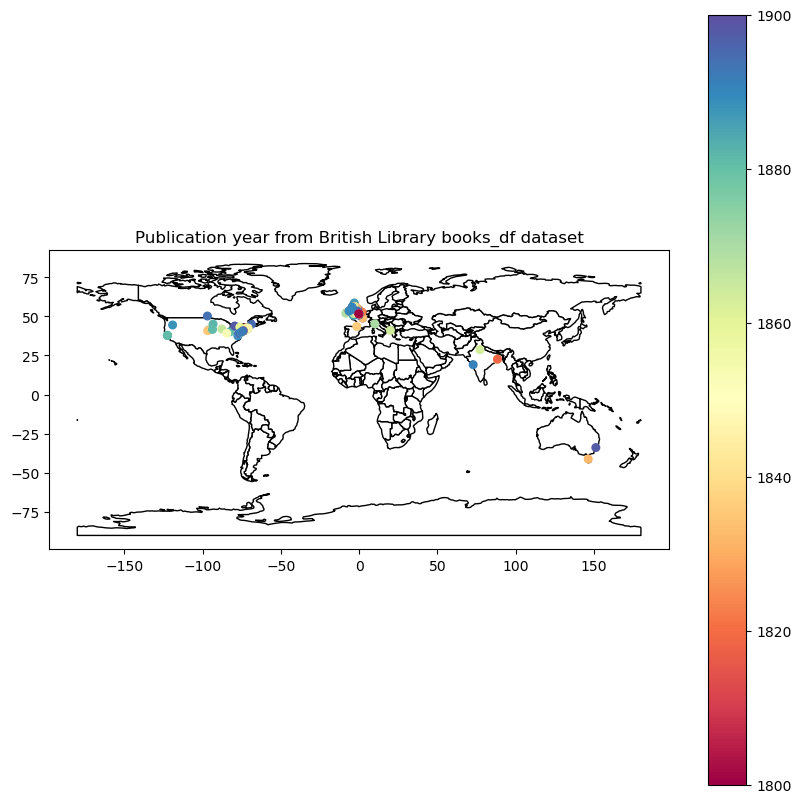

In [ ]:
# Commençons enocre avec un fond de carte
ax=world.plot(color='white', edgecolor='black', figsize=(10,10))

# Mais cette fois, colorons les points selon l'année de publication.
# Et les limites de couleur seront entre les années 1800 et 1900

gdf_withyear = gdf.loc[gdf['datefield'].str.isnumeric()]
gdf_withyear['datefield'] = gdf_withyear['datefield'].astype(int)

gdf_withyear.plot(ax=ax, column='datefield', marker='o', markersize=30, cmap='Spectral', legend=True, vmin=1800, vmax=1900)

# Si l'on veut zoomer sur la Grande-Bretagne, il suffit de spécifier les limites des axes.
#ax.set_xlim(-12, 10)
#ax.set_ylim(40, 60)

# Ajoutons un titre
ax.set_title('Publication year from British Library books_df dataset')

plt.show()

## 3.3. Combiner visualisation et cartographie

Enfin, pour conclure, voyons voir comment combiner les deux : par exemple si vous voulez combiner une carte avec des visualisations statistiques.

Pour faire cela, il suffit de créer une figure `matplotlib` avec deux axes, dont l'un sera votre carte, et l'autre sera l'autre graphe:

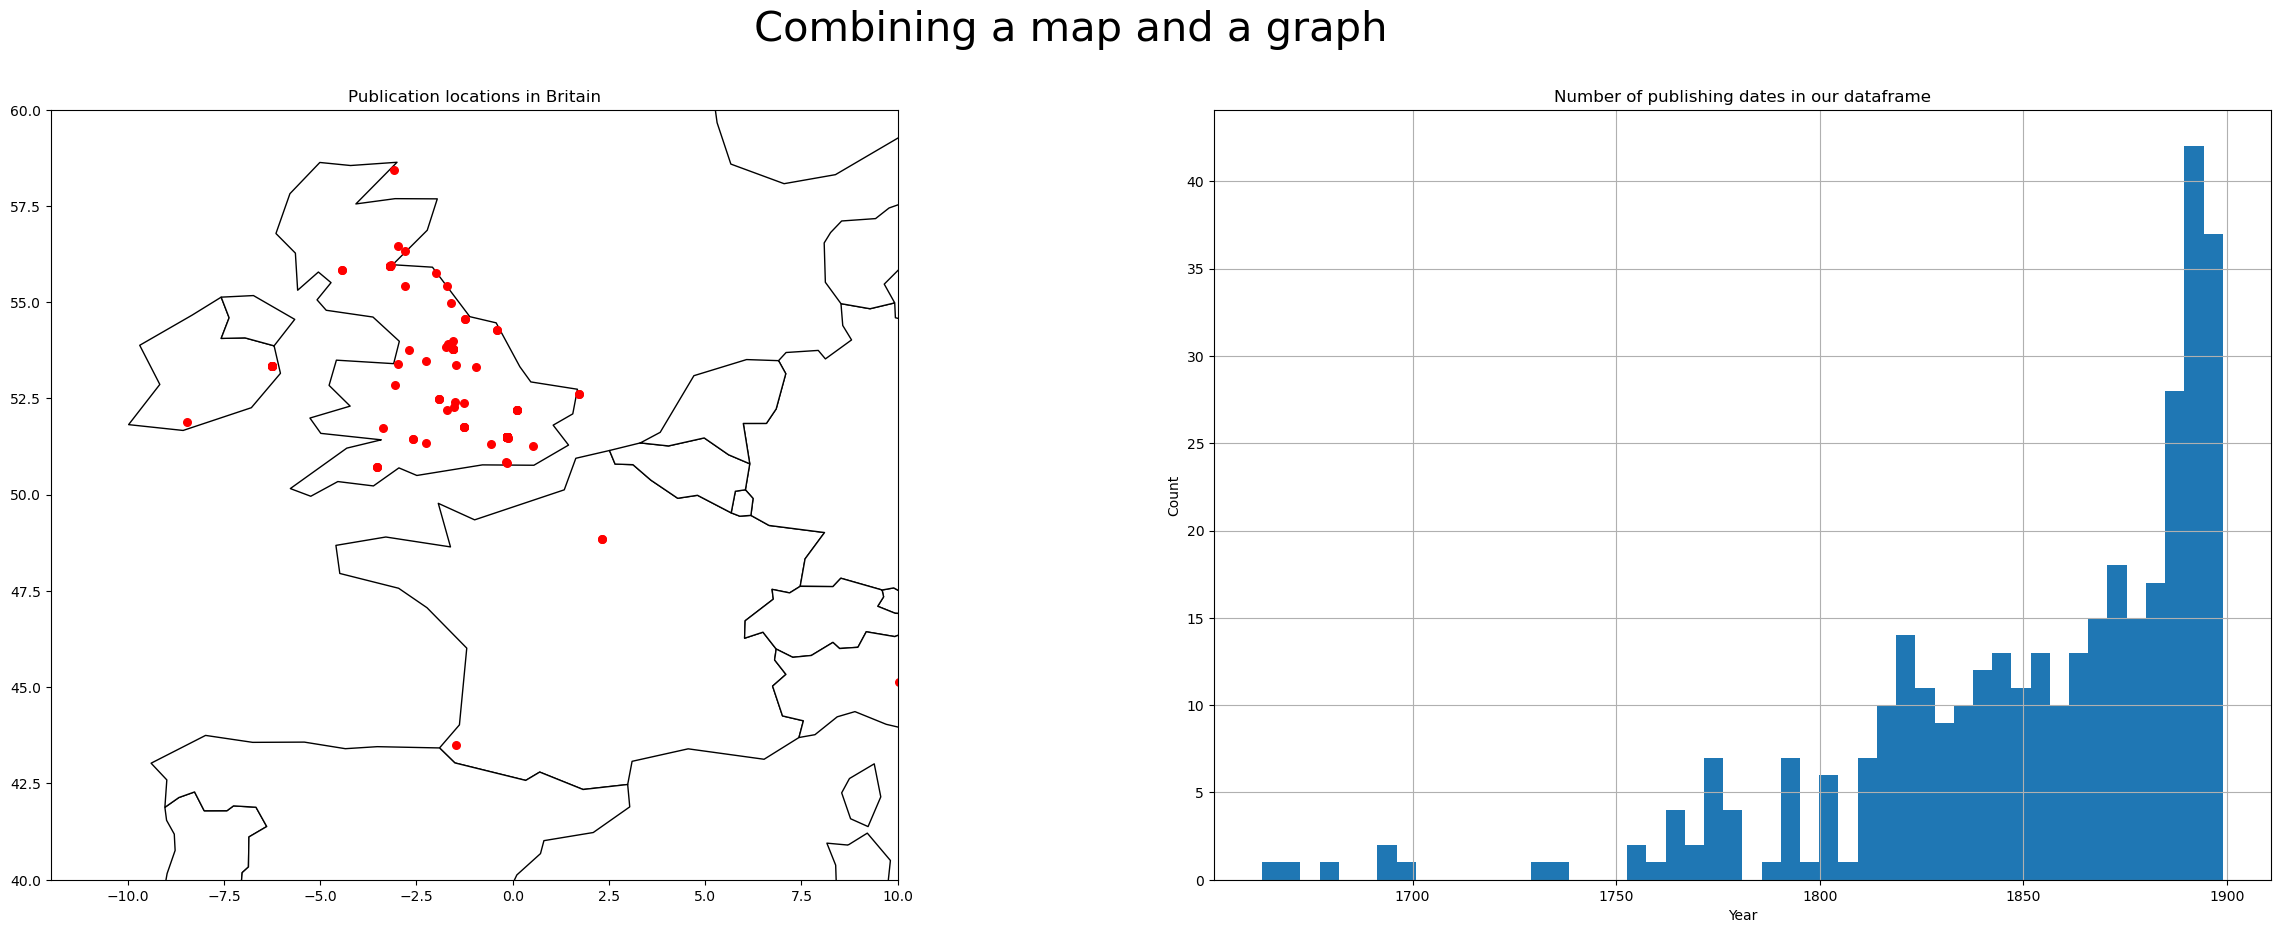

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(30,10))

map_axis = axes[0]
graph_axis = axes[1]

# Commençons avec l'axe cartographique
world.plot(ax = map_axis, color='white', edgecolor='black')
gdf_withyear.plot(ax = map_axis, color='red', marker='o', markersize=30)
map_axis.set_xlim(-12, 10)
map_axis.set_ylim(40, 60)
map_axis.set_title('Publication locations in Britain')

# Et maintenant l'axe statistique
gdf_withyear['datefield'].hist(ax=graph_axis, bins=50)
graph_axis.set_title('Number of publishing dates in our dataframe')
graph_axis.set_xlabel('Year')
graph_axis.set_ylabel('Count')

fig.suptitle('Combining a map and a graph', fontsize=30)

plt.show()

## 3.4. Bonus: Visualisation interactive

Il peut être tentant de réaliser quelques visualisations interactives, par exemple à consulter sur un site.

Pour cela, nous utiliserons le package `folium`

In [1]:
import numpy as np

data = (
    np.random.normal(size=(100, 3)) * np.array([[1, 1, 1]]) + np.array([[48, 5, 1]])
).tolist()

In [7]:
data = [(i[0],i[1],1) for i in located_books['coords'].values]

NameError: name 'located_books' is not defined

In [ ]:
import folium
from folium.plugins import HeatMap

m = folium.Map([48.0, 5.0], zoom_start=6)

HeatMap(data).add_to(m)

for i, row in located_books.iterrows():
    folium.CircleMarker([row['coords'][0], row['coords'][1]], radius=20,
                        fill_opacity=0, fill=True, color=None,
                        tooltip=f'{row['title']} ({row['datefield']})', icon=None).add_to(m)


m

In [4]:
m.save('folium_map.html')